**Install Libraries**

In [1]:
!pip install tensorflow matplotlib seaborn scikit-learn pillow tqdm --quiet
print("Done!")

Done!


**Upload and unzip the dataset**

In [2]:
from google.colab import files
import zipfile, os

# Upload your zipped dataset
uploaded = files.upload()  # Select your cinnamon_dataset.zip

# Unzip it
for filename in uploaded:
    with zipfile.ZipFile(filename, 'r') as z:
        z.extractall('/content/')
    print(f"Unzipped: {filename}")

print("Folder contents:", os.listdir('/content/cinnamon_dataset'))

Saving cinnamon_dataset.zip to cinnamon_dataset.zip
Unzipped: cinnamon_dataset.zip
Folder contents: ['test', 'train', 'val']


**Configuration**

In [3]:
import os, random, numpy as np, warnings
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Config
BASE_DIR    = '/content/cinnamon_dataset'
TRAIN_DIR   = os.path.join(BASE_DIR, 'train')
VAL_DIR     = os.path.join(BASE_DIR, 'val')
TEST_DIR    = os.path.join(BASE_DIR, 'test')
MODEL_PATH  = '/content/cinnamon_model.keras'

CLASSES     = ['Healthy', 'Rough_Bark_Disease', 'Stripe_Canker']
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = 224
BATCH_SIZE  = 32

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("Config ready!")

TensorFlow: 2.19.0
GPU: True
Config ready!


**Check Dataset & Visualize Samples**

Dataset Summary:

  [Train]
    Healthy                   1248 images
    Rough_Bark_Disease        126 images
    Stripe_Canker             134 images

  [Val]
    Healthy                   139 images
    Rough_Bark_Disease        16 images
    Stripe_Canker             17 images

  [Test]
    Healthy                   76 images
    Rough_Bark_Disease        16 images
    Stripe_Canker             17 images



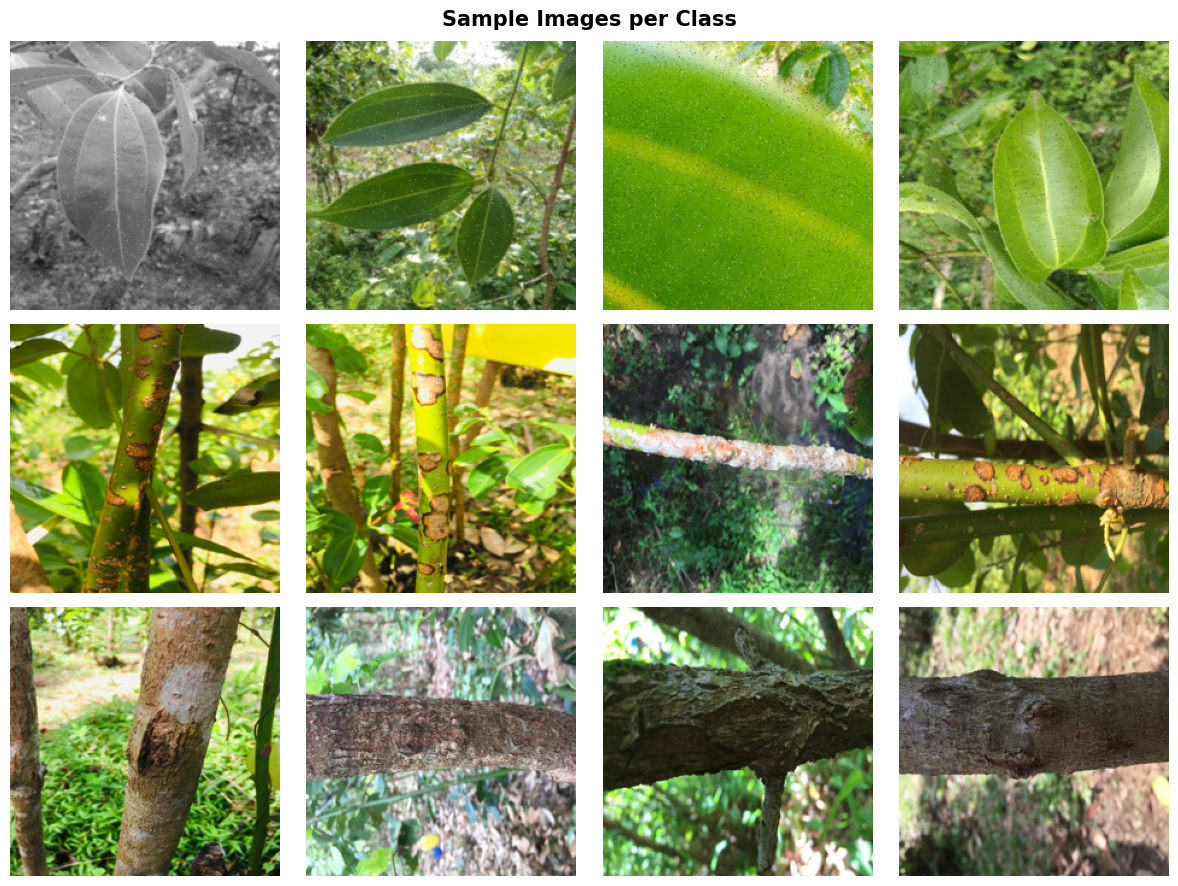

In [4]:
# Count images per class
print("Dataset Summary:\n")
for split, split_dir in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    print(f"  [{split}]")
    for cls in CLASSES:
        path = os.path.join(split_dir, cls)
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        print(f"    {cls:<25} {count} images")
    print()

# Show sample images from each class
fig, axes = plt.subplots(len(CLASSES), 4, figsize=(12, len(CLASSES) * 3))
fig.suptitle('Sample Images per Class', fontsize=15, fontweight='bold')

for row, cls in enumerate(CLASSES):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    images  = os.listdir(cls_dir)[:4]
    for col, img_name in enumerate(images):
        img = Image.open(os.path.join(cls_dir, img_name)).resize((IMG_SIZE, IMG_SIZE))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls.replace('_', '\n'), fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**Data Augmentation & Generators**

In [5]:
# Augmentation for training only
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    classes=CLASSES, shuffle=True, seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    classes=CLASSES, shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    classes=CLASSES, shuffle=False
)

print(f"Train: {train_gen.n} images | Val: {val_gen.n} | Test: {test_gen.n}")
print(f"Class indices: {train_gen.class_indices}")

Found 1508 images belonging to 3 classes.
Found 172 images belonging to 3 classes.
Found 109 images belonging to 3 classes.
Train: 1508 images | Val: 172 | Test: 109
Class indices: {'Healthy': 0, 'Rough_Bark_Disease': 1, 'Stripe_Canker': 2}


**Build the Model**

In [6]:
def build_model():
    base = EfficientNetB3(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False  # Freeze base for Phase 1

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base

model, base_model = build_model()
model.summary()
print("Model built!")

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,708,722 (44.67 MB)

 Trainable params: 922,115 (3.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

Model built!


**Phase 1 Training (Frozen Base)**

In [7]:
callbacks = [
    ModelCheckpoint(MODEL_PATH, monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

print("Phase 1: Training classification head (base frozen)...")
history1 = model.fit(
    train_gen, epochs=15,
    validation_data=val_gen,
    callbacks=callbacks, verbose=1
)
print(f"Best Val Accuracy: {max(history1.history['val_accuracy'])*100:.2f}%")

Phase 1: Training classification head (base frozen)...
Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7743 - loss: 0.8989
Epoch 1: val_accuracy improved from None to 0.80814, saving model to /content/cinnamon_model.keras

Epoch 1: finished saving model to /content/cinnamon_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.7653 - loss: 0.9380 - val_accuracy: 0.8081 - val_loss: 0.6739 - learning_rate: 0.0010
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.7923 - loss: 0.7916
Epoch 2: val_accuracy did not improve from 0.80814
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 833ms/step - accuracy: 0.7938 - loss: 0.7671 - val_accuracy: 0.8081 - val_loss: 0.7634 - learning_rate: 0.0010
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.8166 - loss: 0.6281
Epoch 3: val_accuracy improved from 0.80814 to 0.81395, saving model to /content/cinnamon_model.keras

Epoch 3: finished saving model to /content/cinnamon_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━

**Phase 2 Fine-Tuning**

In [8]:
# Unfreeze top 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # Much lower LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Fine-tuning top 30 layers...")
history2 = model.fit(
    train_gen, epochs=25,
    validation_data=val_gen,
    callbacks=callbacks, verbose=1
)
print(f"Best Val Accuracy: {max(history2.history['val_accuracy'])*100:.2f}%")

Fine-tuning top 30 layers...
Epoch 1/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8075 - loss: 0.6376
Epoch 1: val_accuracy did not improve from 0.81395
48/48 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.8110 - loss: 0.6103 - val_accuracy: 0.8081 - val_loss: 0.6428 - learning_rate: 1.0000e-05
Epoch 2/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - accuracy: 0.8285 - loss: 0.5628
Epoch 2: val_accuracy did not improve from 0.81395
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 829ms/step - accuracy: 0.8223 - loss: 0.5836 - val_accuracy: 0.8081 - val_loss: 0.5656 - learning_rate: 1.0000e-05
Epoch 3/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.8158 - loss: 0.5574
Epoch 3: val_accuracy did not improve from 0.81395
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 828ms/step - accuracy: 0.8143 - loss: 0.5595 - val_accuracy: 0.8081 - val_loss: 0.5515 - learning_rate: 1.0000e-05
Epoch 4/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 772ms/step - accuracy: 0.8208 - loss: 0.5722
Epoch 4: val_accuracy did not improve fro

 **Plot Training Curves**

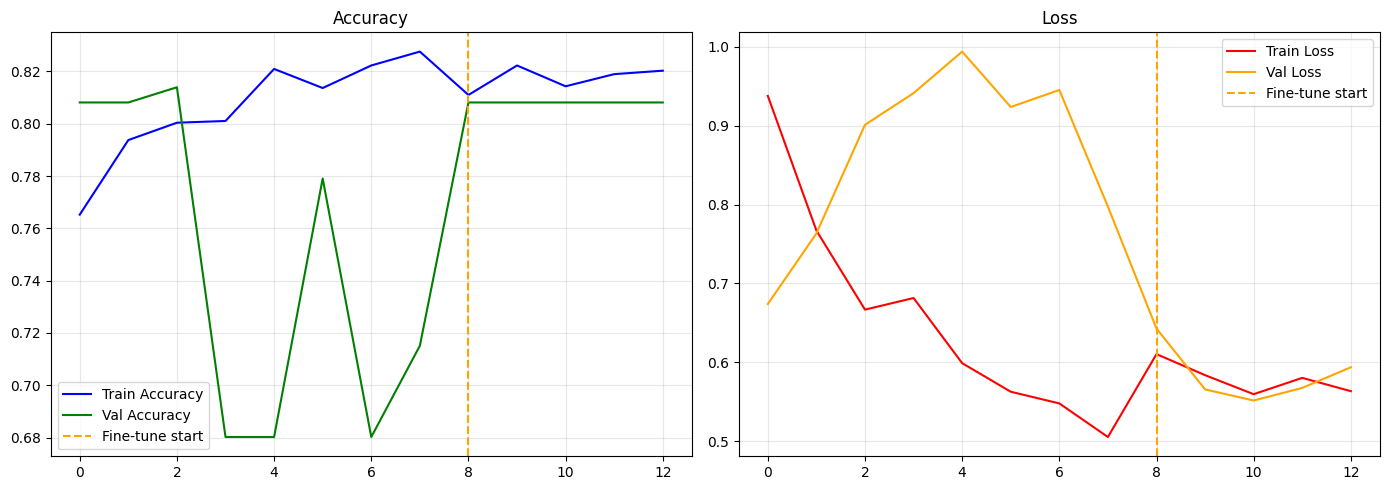

In [9]:
# Combine both phases
acc  = history1.history['accuracy']    + history2.history['accuracy']
val  = history1.history['val_accuracy']+ history2.history['val_accuracy']
loss = history1.history['loss']        + history2.history['loss']
v_loss=history1.history['val_loss']   + history2.history['val_loss']
p1_end = len(history1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(acc, label='Train Accuracy', color='blue')
ax1.plot(val, label='Val Accuracy', color='green')
ax1.axvline(p1_end, color='orange', linestyle='--', label='Fine-tune start')
ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(loss, label='Train Loss', color='red')
ax2.plot(v_loss, label='Val Loss', color='orange')
ax2.axvline(p1_end, color='orange', linestyle='--', label='Fine-tune start')
ax2.set_title('Loss'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Evaluate on Test Set**

4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 6s/step - accuracy: 0.6972 - loss: 0.9413

Test Accuracy : 69.72%
4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step

Classification Report:
                    precision    recall  f1-score   support

           Healthy       0.72      1.00      0.84        76
Rough_Bark_Disease       0.00      0.00      0.00        16
     Stripe_Canker       0.00      0.00      0.00        17

          accuracy                           0.70       109
         macro avg       0.24      0.33      0.28       109
      weighted avg       0.50      0.70      0.58       109



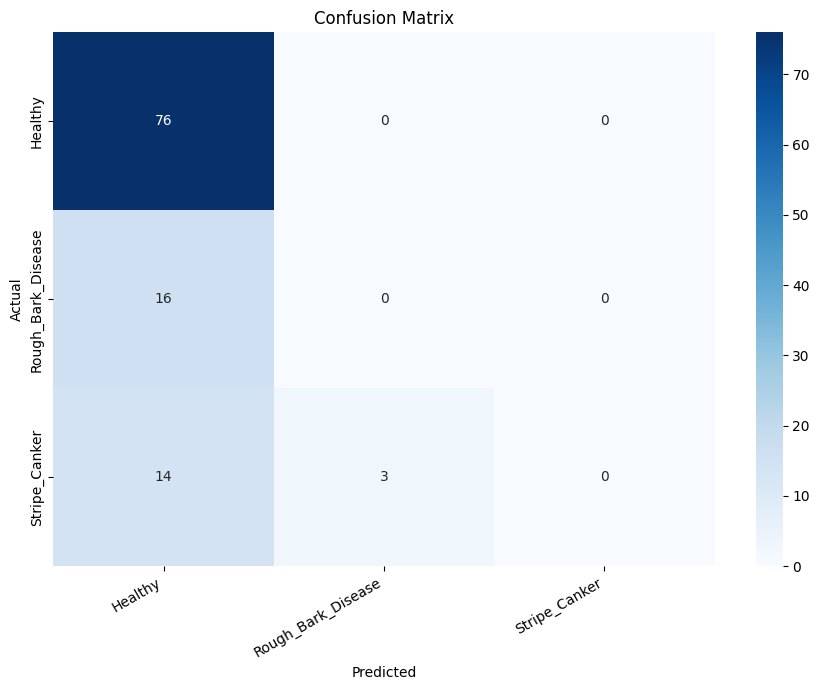

In [10]:
# Load best model
best_model = keras.models.load_model(MODEL_PATH)

# Evaluate
results = best_model.evaluate(test_gen, verbose=1)
print(f"\nTest Accuracy : {results[1]*100:.2f}%")

# Confusion matrix
test_gen.reset()
y_pred = np.argmax(best_model.predict(test_gen), axis=1)
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Predict on a New Image**

Upload a cinnamon plant image:


Saving IMG_E4843.JPG to IMG_E4843.JPG


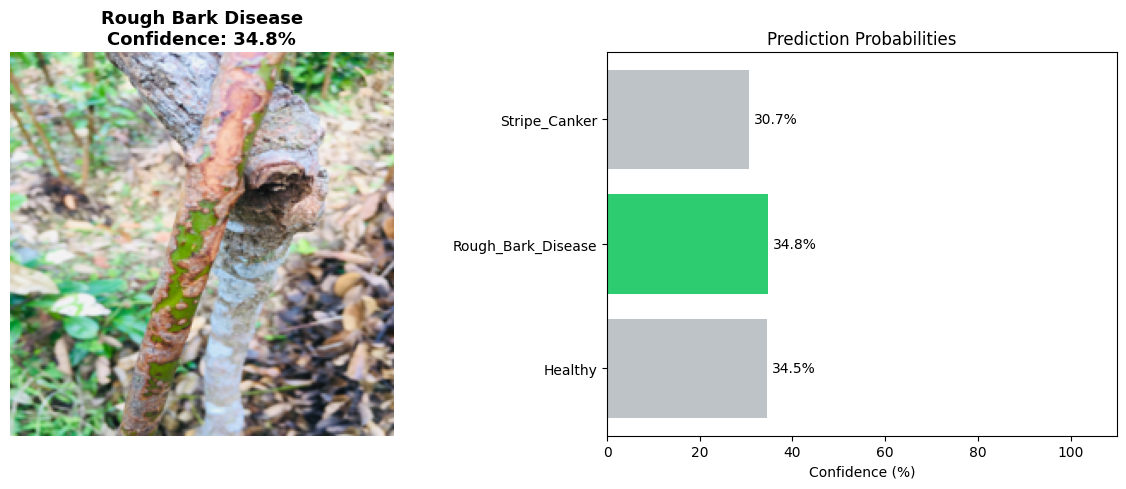


 Result   : Rough Bark Disease
 Confidence: 34.81%
 Advice   :  Apply copper fungicide. Remove infected bark. Improve drainage.


In [16]:
from google.colab import files

DISEASE_ADVICE = {
    'Healthy':             ' Plant is healthy. Continue regular care.',
    'Rough_Bark_Disease':  ' Apply copper fungicide. Remove infected bark. Improve drainage.',
    'Stripe_Canker':       ' Improve soil drainage. Remove infected parts. Apply phosphonate.',
}

def predict_image(img_path, model):
    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = np.expand_dims(np.array(img) / 255.0, axis=0)
    probs = model.predict(arr, verbose=0)[0]
    idx = np.argmax(probs)
    cls = CLASSES[idx]
    conf = probs[idx] * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.imshow(img); ax1.axis('off')
    ax1.set_title(f"{cls.replace('_',' ')}\nConfidence: {conf:.1f}%", fontsize=13, fontweight='bold')

    colors = ['#2ecc71' if c == cls else '#bdc3c7' for c in CLASSES]
    ax2.barh(CLASSES, probs * 100, color=colors)
    ax2.set_xlabel('Confidence (%)')
    ax2.set_title('Prediction Probabilities')
    ax2.set_xlim(0, 110)
    for i, p in enumerate(probs):
        ax2.text(p*100 + 1, i, f'{p*100:.1f}%', va='center')

    plt.tight_layout()
    plt.show()

    print(f"\n Result   : {cls.replace('_', ' ')}")
    print(f" Confidence: {conf:.2f}%")
    print(f" Advice   : {DISEASE_ADVICE[cls]}")

# Upload and predict
print("Upload a cinnamon plant image:")
uploaded = files.upload()
for fname in uploaded:
    predict_image(fname, best_model)

**Save & Download Model**

In [17]:
import json
from google.colab import files

# Save full model
best_model.save('/content/cinnamon_disease_final.keras')

# Save TFLite version (for mobile apps)
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open('/content/cinnamon_disease.tflite', 'wb') as f:
    f.write(tflite_model)

# Save class labels
with open('/content/class_names.json', 'w') as f:
    json.dump(CLASSES, f)

print("All files saved! Downloading...")
files.download('/content/cinnamon_disease_final.keras')
files.download('/content/cinnamon_disease.tflite')
files.download('/content/class_names.json')

Saved artifact at '/tmp/tmpbbis7rll'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139952331562768: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139952331563536: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139953437074320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139952336815312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139952336814928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139952336816080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139952336816272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139952336816464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139952336814352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139952336815888: TensorSpec(shape=(), dtype=tf.resource, name=Non

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>